In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score, roc_curve)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("heart.csv")
print("Shape:", df.shape)
print(df.isnull().sum())
print(df['output'].value_counts())

Shape: (303, 14)
age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64
output
1    165
0    138
Name: count, dtype: int64


In [5]:
X = df.drop(columns=['output'])
y = df['output']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM (RBF)": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
}
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [17]:
results = []
roc_data = {}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    proba = model.predict_proba(X_test_s)[:, 1]

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)
    cv_acc = cross_val_score(model, X_train_s, y_train, cv=5).mean()

    results.append({
        "Model": name, "Accuracy": acc, "Precision": prec,
        "Recall": rec, "F1": f1, "AUC": auc, "CV_Accuracy": cv_acc
    })
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_data[name] = (fpr, tpr, auc)

    print(f"\n--- {name} ---")
    print(confusion_matrix(y_test, pred))
results_df = pd.DataFrame(results).sort_values("AUC", ascending=False)
print("\n\nFinal comparison:")
print(results_df.to_string(index=False))
results_df.to_csv("model_comparison.csv", index=False)



--- Logistic Regression ---
[[19  9]
 [ 3 30]]

--- Random Forest ---
[[18 10]
 [ 1 32]]

--- SVM (RBF) ---
[[19  9]
 [ 2 31]]

--- KNN ---
[[20  8]
 [ 3 30]]


Final comparison:
              Model  Accuracy  Precision   Recall       F1      AUC  CV_Accuracy
      Random Forest  0.819672   0.761905 0.969697 0.853333 0.906385     0.830782
                KNN  0.819672   0.789474 0.909091 0.845070 0.883658     0.810119
          SVM (RBF)  0.819672   0.775000 0.939394 0.849315 0.883117     0.801956
Logistic Regression  0.803279   0.769231 0.909091 0.833333 0.869048     0.830867


In [18]:
# Best model = Random Forest usually -> feature importance
best_name = results_df.iloc[0]["Model"]
print("\nBest model by AUC:", best_name)

rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature importances (Random Forest):")
print(importances)



Best model by AUC: Random Forest

Feature importances (Random Forest):
cp          0.152366
thalachh    0.114802
thall       0.111941
oldpeak     0.107450
caa         0.089717
chol        0.083015
age         0.079596
trtbps      0.074055
exng        0.067921
slp         0.057841
sex         0.028329
restecg     0.023052
fbs         0.009917
dtype: float64


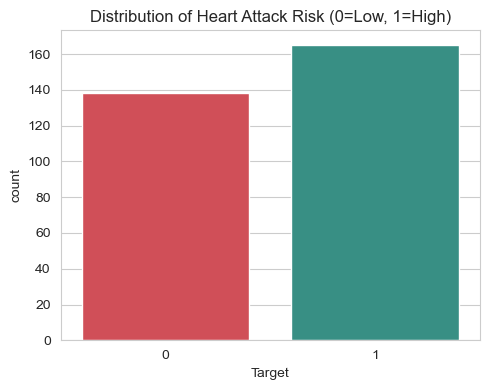

In [27]:
# Plots
sns.set_style("whitegrid")

# 1. Target distribution
plt.figure(figsize=(5,4))
sns.countplot(x='output', hue='output', data=df, palette=['#e63946','#2a9d8f'], legend=False)
plt.title("Distribution of Heart Attack Risk (0=Low, 1=High)")
plt.xlabel("Target")
plt.tight_layout()
plt.savefig("target_distribution.png", dpi=150)
plt.show()

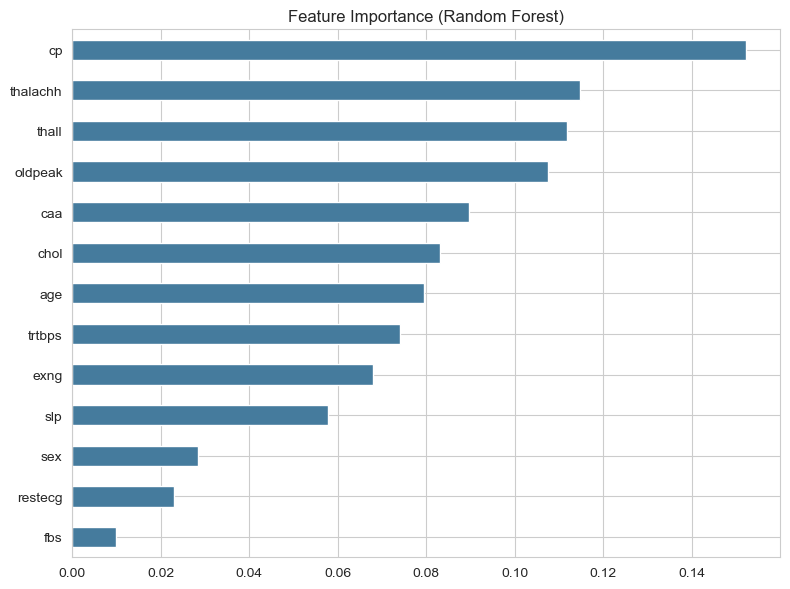

In [28]:
# 3. Feature importance
plt.figure(figsize=(8,6))
importances.plot(kind='barh', color='#457b9d')
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

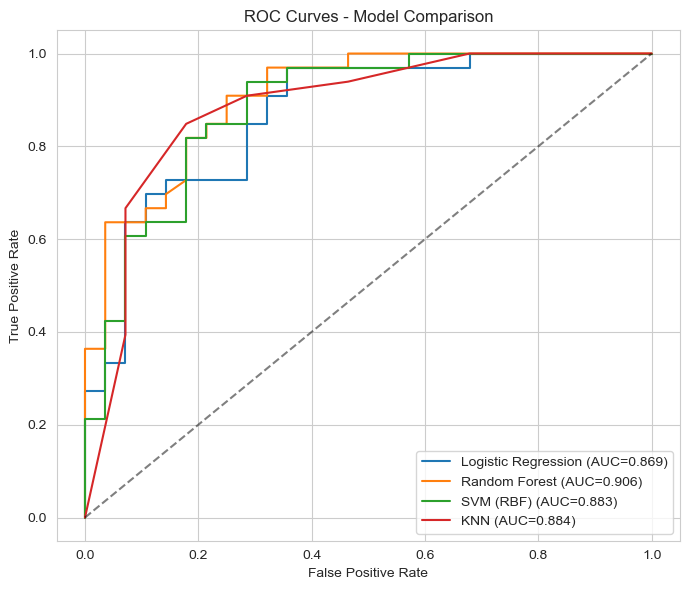

In [29]:
# 4. ROC curves
plt.figure(figsize=(7,6))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

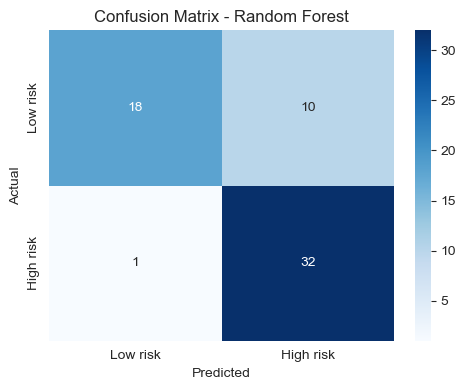


Done.


In [30]:
# 5. Confusion matrix for best model (Random Forest)
best_model = models["Random Forest"]
pred_best = best_model.predict(X_test_s)
cm = confusion_matrix(y_test, pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low risk','High risk'], yticklabels=['Low risk','High risk'])
plt.title("Confusion Matrix - Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("\nDone.")
